# GReinSS — Hands-on Tutorial
### Generative Reinforcement Learning of Structured States
*NCI Spring School on Algorithmic Cancer Biology*

Learn a distribution over **discrete latent states** $S$ from **indirect observations** $X$, given only the forward model $\Pr(X\mid S)$.

**What you supply is just two functions:**
1. a way to **generate** a state $S$ (grow it action by action), and
2. the likelihood $\Pr(X\mid S)$.

GReinSS trains a policy $\Pr(S\mid\theta)$ by policy gradients with the **dynamically rescaled reward**
$$r(\tau)=\sum_{i=1}^N \frac{\Pr(X_i\mid\tau)}{\Pr(X_i\mid\theta)},$$
which makes the gradient an **unbiased estimator** of $\frac{d}{d\theta}\log\Pr(X_{1:N}\mid\theta)$ (maximum likelihood).

**Notebook plan**
- **Setup**
- **Demo 1 — Set reconstruction** (trained *live*, with ground truth): recover binary sets from noisy measurements and beat naive thresholding.
- **Intuition — the toy example**: why the denominator matters, shown numerically.
- **Demo 2 — Graph inference** (pre-trained): reconstruct latent directed graphs from random-walk endpoints and score $F_1$.


## Setup

Point Python at the GReinSS `code/` directory and import the library. We also patch `torch.load` (newer PyTorch defaults to `weights_only=True`, which cannot load these pickled models).

In [1]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- locate the tutorial dir, the GReinSS code (git submodule at tutorial/code), and assets ---
TUTORIAL = os.getcwd()                       # run this notebook from the tutorial/ directory
ASSETS   = os.path.join(TUTORIAL, 'assets')
CODE     = os.path.join(TUTORIAL, 'code')    # git submodule -> elkebir-group/GReinSS
if not os.path.isdir(CODE):                  # fallback to a sibling ../code checkout
    CODE = os.path.abspath(os.path.join(TUTORIAL, '..', 'code'))
sys.path.insert(0, CODE)
os.chdir(CODE)
print('tutorial dir:', TUTORIAL)
print('GReinSS code:', CODE)

# --- PyTorch >= 2.6 loads with weights_only=True by default; these models need False ---
_orig_load = torch.load
torch.load = lambda *a, **k: _orig_load(*a, **{**k, 'weights_only': False})

from sharedGen import (GeneratorNet, gClass, train_model_off_policy,
                       simpleInference)
np.random.seed(0)
torch.manual_seed(0)
print('numpy', np.__version__, '| torch', torch.__version__, '| ready')


tutorial dir: /Users/melkebir/Projects/claude/research/GReinSS/tutorial
GReinSS code: /Users/melkebir/Projects/claude/research/GReinSS/tutorial/code


numpy 2.2.6 | torch 2.11.0 | ready


---
# Demo 1 — Set reconstruction *(trained live)*

**Problem.** Each latent state $S^*_i$ is a **subset** of a universe $\mathcal U$ of $|\mathcal U|$ elements.
We never see $S^*_i$; we observe a noisy real-valued vector
$$X_{i,j}\sim\mathcal N(1,\sigma^2)\ \text{if}\ j\in S^*_i,\qquad X_{i,j}\sim\mathcal N(0,\sigma^2)\ \text{otherwise.}$$

This is the shape of many assays: noisy per-element readouts of which conditions are "on"
(active genes from expression, detected chemicals from mass-spec intensities, ...).

We generate the ground-truth sets with **shared structure** — each set is a union of a few reusable
"modules" — so that a *shared* model $\Pr(S\mid\theta)$ can pool information across observations.
The naive baseline, **thresholding** each observation at 0.5, treats every element independently.


observations X: (200, 20)    (ground-truth S* is hidden from the model)


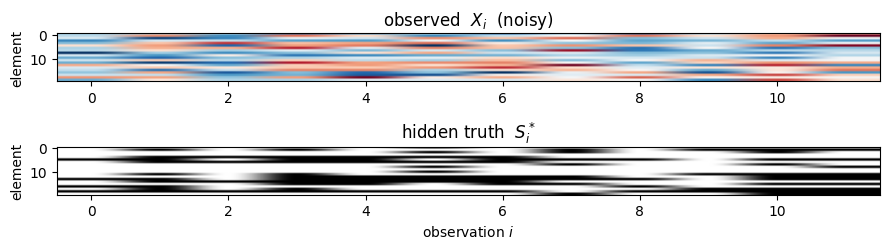

In [2]:
# ---- generate ground-truth sets (union of reusable modules) + noisy observations ----
np.random.seed(0); torch.manual_seed(0)
U       = 20      # universe size |U|
N       = 200     # number of observations
sigma   = 0.5     # observation noise
n_mod, mod_size = 8, 4

modules = [np.random.choice(U, mod_size, replace=False) for _ in range(n_mod)]
truth = np.zeros((N, U))
for i in range(N):
    k = np.random.randint(1, 4)                       # 1-3 modules per set
    for m in np.random.choice(n_mod, k, replace=False):
        truth[i, modules[m]] = 1
observations = truth + np.random.randn(N, U) * sigma  # <-- indirect observations X

print('observations X:', observations.shape, '   (ground-truth S* is hidden from the model)')

# peek: noisy observation (top) vs the hidden true set (bottom) for 12 examples
fig, ax = plt.subplots(2, 1, figsize=(9, 2.6))
ax[0].imshow(observations[:12].T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=2)
ax[0].set_ylabel('element'); ax[0].set_title('observed  $X_i$  (noisy)')
ax[1].imshow(truth[:12].T, aspect='auto', cmap='Greys', vmin=0, vmax=1)
ax[1].set_ylabel('element'); ax[1].set_xlabel('observation $i$'); ax[1].set_title('hidden truth  $S^*_i$')
plt.tight_layout(); plt.show()


### The two ingredients you provide

**(1) The likelihood $\Pr(X\mid S)$.** For Gaussian noise this is just a squared-error term.
GReinSS wants a *vectorized* `multi_x_given_g(states, observations)` returning the matrix of
$\log\Pr(X_i\mid S_j)$ — states are binary vectors here, so $S$ *is* the mean of $X$.

**(2) The generator.** `GeneratorNet` is a policy that builds a set by adding elements one at a
time (then a stop action). You just pick its size.

In [3]:
# (1) vectorized log Pr(X | S):  states are 0/1 vectors; X ~ N(state, sigma^2)
def multi_x_given_g(states, obs):
    obs    = torch.tensor(obs).float().to(states.device)
    states = states.reshape(states.shape[0], 1, states.shape[1])   # (n_states, 1, U)
    obs    = obs.reshape(1, obs.shape[0], obs.shape[1])            # (1, n_obs,  U)
    return -0.5 * torch.sum((states - obs) ** 2, axis=2) / (sigma ** 2)

# (2) the policy that generates sets, plus hyperparameters -> a single rule object
rule = gClass()
rule.graphSize          = U                       # size of the state (universe size)
rule.observations_batch = observations            # the data X_{1:N}
rule.batchSize          = 1000                     # states sampled per step (large = better)
rule.learning_rate      = 1e-3
rule.model              = GeneratorNet(U, 64)      # 64 hidden units
rule.multi_x_given_g    = multi_x_given_g
print('rule object ready — generator + Pr(X|S) supplied.')


rule object ready — generator + Pr(X|S) supplied.


### Train — live

We run a few hundred policy-gradient steps (~10 s). Watch the **median log-likelihood**
$\log\Pr(X_i\mid\theta)$ climb toward 0: the model is learning the distribution of sets that
best explains *all* the observations at once.

Epoch 1/400, Average Reward: -10.378515243530273, Median: -10.192410469055176


Epoch 11/400, Average Reward: -8.920506477355957, Median: -8.695868492126465
Epoch 21/400, Average Reward: -8.679587364196777, Median: -8.75096321105957


Epoch 31/400, Average Reward: -8.403705596923828, Median: -8.171660423278809
Epoch 41/400, Average Reward: -8.22487735748291, Median: -7.9022536277771


Epoch 51/400, Average Reward: -8.012055397033691, Median: -7.7933807373046875
Epoch 61/400, Average Reward: -8.015185356140137, Median: -7.482708930969238


Epoch 71/400, Average Reward: -7.868590831756592, Median: -7.495805740356445
Epoch 81/400, Average Reward: -7.692442417144775, Median: -7.433252811431885


...

Epoch 311/400, Average Reward: -6.729362964630127, Median: -6.353090286254883
Epoch 321/400, Average Reward: -6.6802496910095215, Median: -6.4462175369262695


Epoch 331/400, Average Reward: -6.707740306854248, Median: -6.423408031463623
Epoch 341/400, Average Reward: -6.6829962730407715, Median: -6.639891624450684


Epoch 351/400, Average Reward: -6.590593338012695, Median: -6.406431198120117
Epoch 361/400, Average Reward: -6.650701999664307, Median: -6.465981960296631


Epoch 371/400, Average Reward: -6.600121021270752, Median: -6.377391338348389
Epoch 381/400, Average Reward: -6.630712985992432, Median: -6.492007255554199


Epoch 391/400, Average Reward: -6.654969692230225, Median: -6.399314880371094

trained in 8.0 s


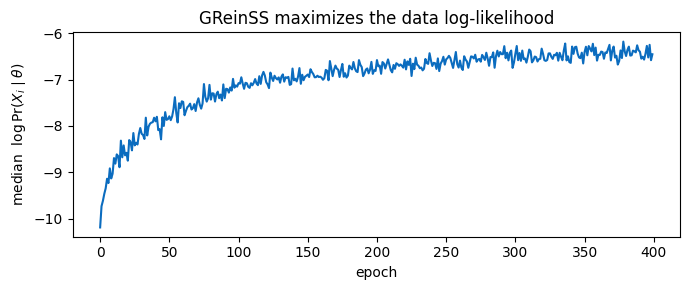

In [4]:
SET_MODEL = './_tutorial_set_model.pt'
t = time.time()
train_model_off_policy(rule, rule.learning_rate, rule.batchSize, offPolicy=False,
                       num_epochs=400, model_filename=SET_MODEL,
                       saveTrainingLoss='./_tutorial_set_loss.npz')
print(f'\ntrained in {time.time()-t:.1f} s')

loss = np.load('./_tutorial_set_loss.npz')['arr_0']
plt.figure(figsize=(7,3))
plt.plot(loss, color='#0b6cbf')
plt.xlabel('epoch'); plt.ylabel('median  $\\log\\Pr(X_i\\mid\\theta)$')
plt.title('GReinSS maximizes the data log-likelihood'); plt.tight_layout(); plt.show()


### Infer the sets, and compare to naive thresholding

`simpleInference` samples from the trained policy and, for each observation $X_i$, returns the
state $\hat S_i=\arg\max_S \Pr(X_i\mid S)\Pr(S\mid\theta)$. Because $\Pr(S\mid\theta)$ is **shared**,
GReinSS can override noisy elements that thresholding gets wrong.

In [5]:
pred = np.array(simpleInference(rule, SET_MODEL)).astype(int)   # GReinSS predictions
thr  = (observations > 0.5).astype(int)                          # naive per-element thresholding

def f1(P, T):
    tp = ((P==1)&(T==1)).sum(); fp = ((P==1)&(T==0)).sum(); fn = ((P==0)&(T==1)).sum()
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    return 2*prec*rec/(prec+rec+1e-9)

print(f"element F1     |  GReinSS {f1(pred,truth):.3f}   vs   thresholding {f1(thr,truth):.3f}")
print(f"exact-set acc  |  GReinSS {(pred==truth).all(1).mean():.2f}     vs   thresholding {(thr==truth).all(1).mean():.2f}")


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17


18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34


35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66


67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82


83
84
85
86
87
88
89
90
91
92
93
94
95
96
97


98
99


tensor(-1.8715, dtype=torch.float64)
element F1     |  GReinSS 0.912   vs   thresholding 0.802
exact-set acc  |  GReinSS 0.42     vs   thresholding 0.04


elements thresholding got wrong that GReinSS corrected: 414
elements thresholding got right that GReinSS broke:     72


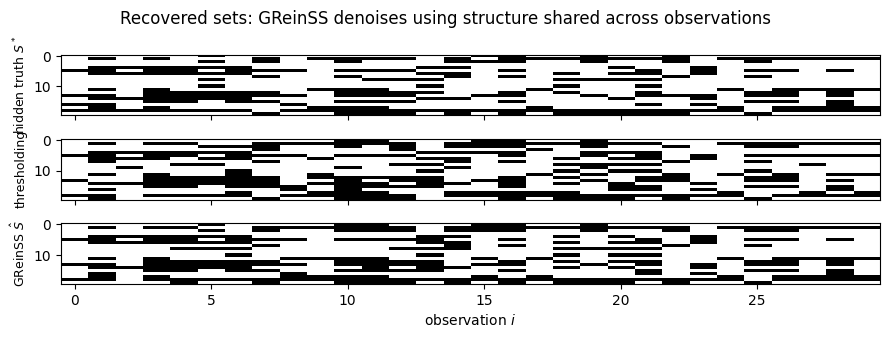

In [6]:
# where does GReinSS fix what thresholding got wrong?  (green = fixed, red = introduced error)
thr_wrong  = (thr  != truth)
pred_wrong = (pred != truth)
fixed   = thr_wrong & ~pred_wrong    # threshold wrong, GReinSS right
broke   = ~thr_wrong &  pred_wrong   # threshold right, GReinSS wrong
print(f"elements thresholding got wrong that GReinSS corrected: {fixed.sum()}")
print(f"elements thresholding got right that GReinSS broke:     {broke.sum()}")

fig, ax = plt.subplots(3, 1, figsize=(9, 3.4), sharex=True)
for a, M, t_ in zip(ax, [truth, thr, pred], ['hidden truth $S^*$', 'thresholding', 'GReinSS $\\hat S$']):
    a.imshow(M[:30].T, aspect='auto', cmap='Greys', vmin=0, vmax=1); a.set_ylabel(t_, fontsize=9)
ax[-1].set_xlabel('observation $i$')
plt.suptitle('Recovered sets: GReinSS denoises using structure shared across observations')
plt.tight_layout(); plt.show()


> **Takeaway.** Same four-line recipe as the README (`gClass` → set `multi_x_given_g` →
> `train_model_off_policy` → `simpleInference`). The shared model $\Pr(S\mid\theta)$ lets GReinSS
> beat independent thresholding — exactly the gain that scales to large universes in the paper.

---
# Intuition — why the denominator matters

A tiny problem shows the whole point. Three states $S_1,S_2,S_3$, two observations $X_1,X_2$:

$$\Pr(X_1\mid S_1)=0.5,\quad \Pr(X_2\mid S_2)=0.3,\quad \Pr(X_2\mid S_3)=0.2,\quad\text{(all others }0).$$

Each state is made by its own trajectory $\tau_j$. We optimize a 3-way softmax policy
$\Pr(\tau_j\mid\theta)$ by policy gradient — once with the **naive** reward
$r'(\tau)=\sum_i\Pr(X_i\mid\tau)$, once with the **GReinSS** reward
$r(\tau)=\sum_i \Pr(X_i\mid\tau)/\Pr(X_i\mid\theta)$.

In [7]:
# Pr(X_i | S_j):  rows = observations X1,X2 ; cols = states S1,S2,S3
PxS = np.array([[0.5, 0.0, 0.0],
                [0.0, 0.3, 0.2]])

def run(dynamic, steps=4000, lr=0.2):
    logits = torch.zeros(3, requires_grad=True)          # policy over the 3 trajectories
    opt = torch.optim.SGD([logits], lr=lr)
    for _ in range(steps):
        p = torch.softmax(logits, 0)                     # Pr(tau_j | theta)
        Px_theta = torch.tensor(PxS, dtype=torch.float) @ p          # Pr(X_i | theta)
        if dynamic:                                       # GReinSS: divide by Pr(X_i|theta)
            r = (torch.tensor(PxS, dtype=torch.float) / Px_theta[:, None]).sum(0)
        else:                                             # naive: raw reward
            r = torch.tensor(PxS.sum(0), dtype=torch.float)
        # policy-gradient surrogate: maximize sum_j detach(r_j) * Pr(tau_j)
        loss = -(r.detach() * p).sum()
        opt.zero_grad(); loss.backward(); opt.step()
    p = torch.softmax(logits, 0).detach().numpy()
    joint = (PxS @ p).prod()                              # Pr(X1|theta) * Pr(X2|theta)
    return p, joint

for name, dyn in [('naive policy gradient', False), ('GReinSS (dynamic reward)', True)]:
    p, joint = run(dyn)
    print(f"{name:26s} Pr(tau) = [{p[0]:.3f} {p[1]:.3f} {p[2]:.3f}]   joint Pr(X1,X2|theta) = {joint:.4f}")


naive policy gradient      Pr(tau) = [0.996 0.002 0.001]   joint Pr(X1,X2|theta) = 0.0005


GReinSS (dynamic reward)   Pr(tau) = [0.500 0.499 0.001]   joint Pr(X1,X2|theta) = 0.0375


**Result.**
- **Naive PG** chases the single highest reward ($\tau_1$), sets $\Pr(\tau_1)\to1$, and drives
  $\Pr(X_2\mid\theta)\to0$ — the joint likelihood collapses to **0**.
- **GReinSS** balances $\Pr(\tau_1)=\Pr(\tau_2)=0.5$, $\Pr(\tau_3)=0$, reaching the **optimal**
  joint likelihood $0.25\times0.15=\mathbf{0.0375}$.

The denominator $\Pr(X_i\mid\theta)$ makes a trajectory's reward *shrink as it succeeds*, so the
policy spreads over exactly the states the data needs instead of collapsing to the argmax.

---
# Demo 2 — Latent graph inference *(pre-trained)*

**Problem.** Each latent state $S^*_i$ is a **directed graph** on 10 nodes (90 possible edges).
We observe only the **start and end points of $k$ absorbing random walks** on the graph — a very
indirect view. The forward model $\Pr(X\mid S)$ follows from the shifted-Laplacian $(L+I)^{-1}$
random-walk process (provided as `sim1_fast_multi`).

This is heavier to train, so we **load a pre-trained policy** (see `tutorial/pretrain_graph.py`) and
its saved ground-truth graphs, then run inference and score edge-recovery $F_1$.

graph observations: (300, 10, 10) | ground-truth graphs: (300, 90)


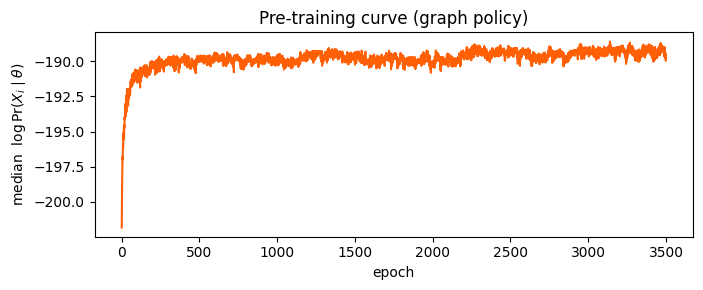

In [8]:
from sharedGen import sim1_log_calculate_pr_x_given_g, sim1_fast_multi

# ASSETS was defined in the setup cell (tutorial/assets)
graph_obs   = np.load(os.path.join(ASSETS, 'graph_obs.npz'))['arr_0']    # (D,10,10) start-end counts
graph_truth = np.load(os.path.join(ASSETS, 'graph_truth.npz'))['arr_0']  # (D,90)   true adjacency (off-diagonal)
GRAPH_MODEL = os.path.join(ASSETS, 'graph_model.pt')
print('graph observations:', graph_obs.shape, '| ground-truth graphs:', graph_truth.shape)

# pre-computed training curve
gloss = np.load(os.path.join(ASSETS, 'graph_loss.npz'))['arr_0']
plt.figure(figsize=(7,3)); plt.plot(gloss, color='#FF5F05')
plt.xlabel('epoch'); plt.ylabel('median  $\\log\\Pr(X_i\\mid\\theta)$')
plt.title('Pre-training curve (graph policy)'); plt.tight_layout(); plt.show()


0
1


2


3
4


5


6
7


...

95


96
97


98


99


tensor(-154.0817, dtype=torch.float64)
inference in 9.4 s   ->  predictions (300, 90)
edge-recovery F1  -  median 0.966   mean 0.941


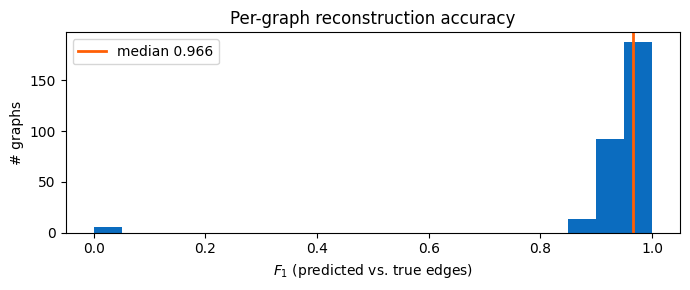

In [9]:
# rebuild the rule object for the graph problem and load the trained policy
STATE = 10 * 9   # 90 directed edges
grule = gClass()
grule.graphSize               = STATE
grule.observations_batch      = graph_obs
grule.batchSize               = 1000
grule.learning_rate           = 1e-3
grule.model                   = GeneratorNet(STATE, 50)
grule.log_calculate_pr_x_given_g = sim1_log_calculate_pr_x_given_g
grule.multi_x_given_g            = sim1_fast_multi

t = time.time()
gpred = np.array(simpleInference(grule, GRAPH_MODEL)).astype(int)   # predicted adjacency (D,90)
print(f'inference in {time.time()-t:.1f} s   ->  predictions {gpred.shape}')

def f1(P, T):
    tp = ((P==1)&(T==1)).sum(); fp = ((P==1)&(T==0)).sum(); fn = ((P==0)&(T==1)).sum()
    prec = tp/(tp+fp+1e-9); rec = tp/(tp+fn+1e-9)
    return 2*prec*rec/(prec+rec+1e-9)

per_graph_f1 = np.array([f1(gpred[i], graph_truth[i]) for i in range(len(gpred))])
print(f"edge-recovery F1  -  median {np.median(per_graph_f1):.3f}   mean {per_graph_f1.mean():.3f}")

plt.figure(figsize=(7,3)); plt.hist(per_graph_f1, bins=20, color='#0b6cbf')
plt.axvline(np.median(per_graph_f1), color='#FF5F05', lw=2, label=f'median {np.median(per_graph_f1):.3f}')
plt.xlabel('$F_1$ (predicted vs. true edges)'); plt.ylabel('# graphs'); plt.legend()
plt.title('Per-graph reconstruction accuracy'); plt.tight_layout(); plt.show()


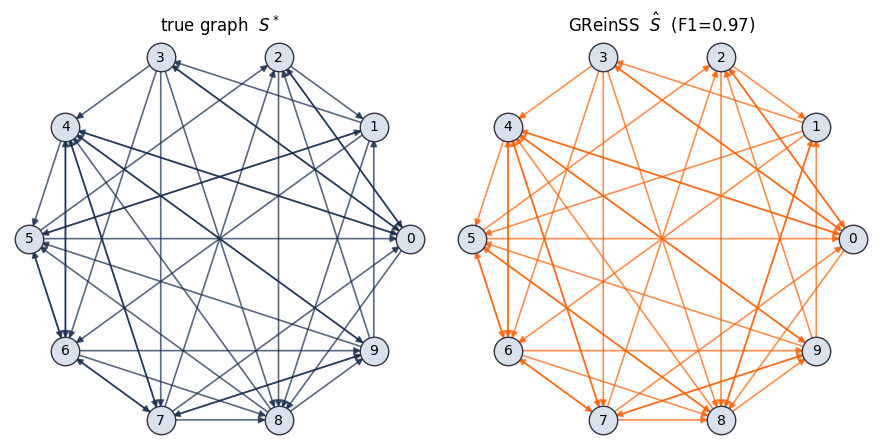

In [10]:
# visualize one reconstruction: true graph vs GReinSS prediction
def vec_to_adj(v, n=10):
    A = np.zeros((n, n), dtype=int); od = np.argwhere(np.eye(n) == 0)
    A[od[:,0], od[:,1]] = v; return A

def draw(A, ax, title, color):
    n = A.shape[0]; ang = np.linspace(0, 2*np.pi, n, endpoint=False)
    xy = np.c_[np.cos(ang), np.sin(ang)]
    for i in range(n):
        for j in range(n):
            if A[i,j]:
                ax.annotate('', xy=xy[j], xytext=xy[i],
                            arrowprops=dict(arrowstyle='-|>', color=color, alpha=.7,
                                            shrinkA=9, shrinkB=9, lw=1.2))
    ax.scatter(xy[:,0], xy[:,1], s=420, color='#d9e2ec', zorder=3, edgecolor='#334')
    for i,(x,y) in enumerate(xy): ax.text(x, y, str(i), ha='center', va='center', zorder=4)
    ax.set_title(title); ax.set_aspect('equal'); ax.axis('off')

idx = int(np.argsort(-per_graph_f1)[len(per_graph_f1)//2])   # a median-accuracy example
fig, ax = plt.subplots(1, 2, figsize=(9, 4.4))
draw(vec_to_adj(graph_truth[idx]), ax[0], f'true graph  $S^*$', '#13294B')
draw(vec_to_adj(gpred[idx]),       ax[1], f'GReinSS  $\\hat S$  (F1={per_graph_f1[idx]:.2f})', '#FF5F05')
plt.tight_layout(); plt.show()


> **Recap — the GReinSS recipe.** For *any* discrete latent structure you can grow incrementally:
> 1. write a **generator** for $S$ (here `GeneratorNet` adds edges/elements),
> 2. write the likelihood **$\Pr(X\mid S)$**,
> 3. `train_model_off_policy(...)`  →  4. `simpleInference(...)`.
>
> Add an **off-policy proposal** for hard instances. The same machinery underlies the cancer
> methods **CloMu** (mutation trees) and **CNRein** (single-cell CNVs), and the RNA-isoform
> results that beat RSEM.